# My own GCN Code for the citation dataset in Planetoid/Cora

### Importing important libraries
<br>
1. Numpy: for handling matrices <br>
2. scipy.sparse: to create a sparse matrix, which only handles 1's and takes less space <br>
3. torch.nn: to use all the layer/model functions for training/evaluating <br>
4. Planetoid: library that downloads our dataset <br>
5. NormalizeFeatures: Each node in cora dataset has features which may be of varying values. We normalise to be able to compare each nodes features to another node's. <br>

In [5]:
import numpy as np
import scipy.sparse as sp
import torch.nn as nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
import torch
import torch.nn.functional as F
from torch.nn import Parameter

### Downloading and understanding the data

In [7]:
dataset = Planetoid(root = '/Users/poorvaichandrasen/GCN_IIST', name = 'Cora', transform = NormalizeFeatures())

Dataset is of type <torch.dataset>
Data is the first instance of this dataset
This dataset is of length 1 => only 1 graph is contained
<br>
1. Num of nodes = 2708
2. Num of edges = 10666
3. Num of features = 1433 [each node has 1433 words, whose frequency is recorded]
4. Num of classes in the entire dataset = 7

<br>
<b>Task:</b> To classify each node into one of the 7 classes

In [9]:
print(type(dataset))
print(dataset[0])
data = dataset[0]
print(data.num_nodes)
print(data.num_features)
print(data.num_edges)
print(dataset.num_classes)

<class 'torch_geometric.datasets.planetoid.Planetoid'>
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
2708
1433
10556
7


### Processing the input

In [11]:
edge_index = data.edge_index

In [2]:
print(type(edge_index))

NameError: name 'edge_index' is not defined

In [15]:
print(edge_index.shape)
print(edge_index)

torch.Size([2, 10556])
tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])


####  This edge index is not an adjacency matrix. Thus we have to convert this to a torch sparse matrix that we can use to multiply with #

In [530]:
num_nodes = 2708
values = torch.ones(edge_index.shape[1])
# Create sparse adjacency matrix
adj_sparse = torch.sparse_coo_tensor(edge_index, values, size=(num_nodes, num_nodes))
adj_sparse.is_sparse

True

In [522]:
# to check if the multiplication takes place
weights = torch.rand((1433, 16), dtype=torch.float)
support = torch.mm(data.x.float(), weights)  # convert sparse matrix to float
output = torch.spmm(adj_sparse, support)

#### Feature matrix:

In [23]:
features = data.x

### Define your model

In [111]:
class myGCNLayer(nn.Module):
    def __init__(self, in_size, out_size, bias = True):
        torch.manual_seed(42)
        super().__init__()
        self.in_size = in_size
        self.out_size = out_size
        self.weights = Parameter(torch.rand(self.in_size, self.out_size))
        if bias:
            self.bias = Parameter(torch.rand(self.out_size))  #keep bias as row vector
        else:
            self.register_parameter('bias', None)
        
    

    # def initialise_parameters(self):
    #     torch.manual_seed(42)
    #     # self.weights = Parameter(torch.rand(self.in_size, self.out_size)) # You are Reassigning parameters here
    #     # if self.bias is not None:
    #     #     self.bias = Parameter(torch.rand(self.out_size))
    #     self.weights.data.uniform_(0, 1) 
    #     if self.bias is not None:
    #         self.bias.data.uniform_(0, 1)
            
    def layer_forward(self, in_features, adj):
        support = torch.mm(in_features, self.weights)
        output = torch.spmm(adj, support)
        if self.bias is not None:
            return output + self.bias
        else:
            return output
            
    def __repr__(self):
        return self.__class__.__name__ + ' (' \
               + str(self.in_size) + ' -> ' \
               + str(self.out_size) + ')'

In [113]:
class myGCNmodel(nn.Module):
    def __init__(self, num_feat, hdn_units, num_class):
        super().__init__()
        self.layer1 = myGCNLayer(num_feat, hdn_units) 
        #Do not keep layers as local variables, they are attributes of the instance
        self.layer2 = myGCNLayer(hdn_units, num_class)
        

    def forward(self, feature_mat, adj_mat): #Do not forget self
        x = F.relu(self.layer1.layer_forward (feature_mat, adj_mat))
        #x = F.dropout(x, self.dropout, training=self.training)
        x = self.layer2.layer_forward (x, adj_mat)
        return F.log_softmax(x, dim=1)

In [168]:
print(adj_sparse)

tensor(indices=tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
                       [   0,    0,    0,  ..., 2707, 2707, 2707]]),
       values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
       size=(2708, 2708), nnz=10556, layout=torch.sparse_coo)


### Training your model

In [116]:
model = myGCNmodel(data.num_features, 16, dataset.num_classes)
print(model)

myGCNmodel(
  (layer1): myGCNLayer (1433 -> 16)
  (layer2): myGCNLayer (16 -> 7)
)


In [118]:
learning_rate = 0.01
decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), 
                             lr=learning_rate, 
                             weight_decay=decay)
# Define loss function (CrossEntropyLoss for Classification Problems with 
# probability distributions)
criterion = torch.nn.CrossEntropyLoss()

In [120]:
def train():
      model.train()
      optimizer.zero_grad() 
      # Use all data as input, because all nodes have node features
      out = model.forward(data.x, adj_sparse)  
      # Only use nodes with labels available for loss calculation --> mask
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  
      loss.backward() 
      optimizer.step()
      return loss
    
def test():
      model.eval()
      out = model(data.x, adj_sparse)
      # Use the class with highest probability.
      pred = out.argmax(dim=1)  
      # Check against ground-truth labels.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  
      # Derive ratio of correct predictions.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  
      return test_acc, pred

In [122]:
losses = []
for epoch in range(0, 1001):
    loss = train()
    losses.append(loss.item())
    if epoch % 100 == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 000, Loss: 55.5257
Epoch: 100, Loss: 0.4217
Epoch: 200, Loss: 0.2941
Epoch: 300, Loss: 0.2335
Epoch: 400, Loss: 0.1976
Epoch: 500, Loss: 0.1732
Epoch: 600, Loss: 0.1552
Epoch: 700, Loss: 0.1412
Epoch: 800, Loss: 0.1298
Epoch: 900, Loss: 0.1203
Epoch: 1000, Loss: 0.1121


In [124]:
accuracy, pred = test()

In [126]:
accuracy


0.695

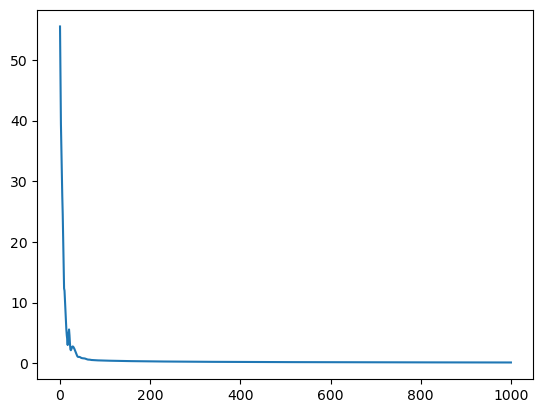

In [44]:
import matplotlib.pyplot as plt
x = np.arange(0,1001)
plot = plt.plot (x, np.array(losses))

In [202]:
out = model.forward(data.x, adj_sparse)
print(out[9])
print(50*'_')
data.y[9]

tensor([-8.6248, -6.7530, -0.0119, -6.1478, -7.0683, -5.3400, -5.9104],
       grad_fn=<SelectBackward0>)
__________________________________________________


tensor(2)

torch.Size([2708, 7])


<Axes: >

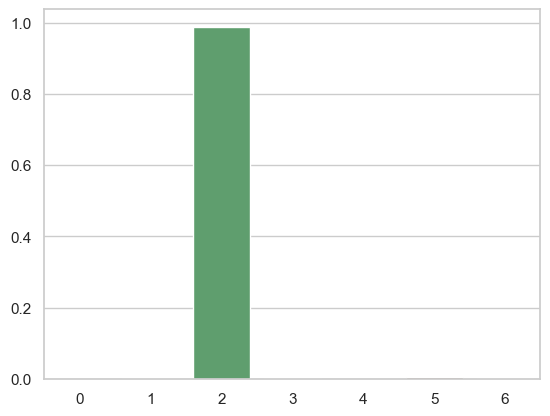

In [244]:
import seaborn as sns
import numpy as np
sample = 9
sns.set_theme(style="whitegrid")
print(model(data.x, adj_sparse).shape)
pred = model(data.x, adj_sparse)
probs = torch.exp(pred)
sns.barplot(x=np.array(range(7)), y=probs[sample].detach().cpu().numpy())

## Model with 3 layers instead

Did not improve accuracy


In [46]:
class myGCNmodel_2(nn.Module):
    def __init__(self, num_feat, hdn_units_1, hdn_units_2, num_class):
        super().__init__()
        self.layer1 = myGCNLayer(num_feat, hdn_units_1) 
        #Do not keep layers as local variables, they are attributes of the instance
        self.layer2 = myGCNLayer(hdn_units_1, hdn_units_2)
        self.layer3 = myGCNLayer(hdn_units_2, num_class)
        

    def forward(self, feature_mat, adj_mat): #Do not forget self
        x = F.relu(self.layer1.layer_forward (feature_mat, adj_mat))
        #x = F.dropout(x, self.dropout, training=self.training)
        x = F.relu(self.layer2.layer_forward (x, adj_mat))
        x = self.layer3.layer_forward (x, adj_mat)
        return F.log_softmax(x, dim=1)

In [223]:
class myGCNmodel_3(nn.Module):
    def __init__(self, num_feat, num_class):
        super().__init__()
        self.layer = myGCNLayer(num_feat, num_class)
        self.layer = myGCNLayer(num_feat, num_class)
        

    def forward(self, feature_mat, adj_mat): #Do not forget self
        x = F.relu(self.layer.layer_forward (feature_mat, adj_mat))
        return F.log_softmax(x, dim=1)

In [225]:
model_2 = myGCNmodel_2(data.num_features, 64, 32, dataset.num_classes)
print(model_2)

myGCNmodel_2(
  (layer1): myGCNLayer (1433 -> 64)
  (layer2): myGCNLayer (64 -> 32)
  (layer3): myGCNLayer (32 -> 7)
)


In [227]:
model_3 = myGCNmodel_3(data.num_features, dataset.num_classes)
print(model_3)

myGCNmodel_3(
  (layer): myGCNLayer (1433 -> 7)
)


In [128]:
def train2():
      model_2.train()
      optimizer.zero_grad() 
      # Use all data as input, because all nodes have node features
      out = model_2.forward(data.x, adj_sparse)  
      # Only use nodes with labels available for loss calculation --> mask
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  
      loss.backward() 
      optimizer.step()
      return loss
    
def test2():
      model_2.eval()
      out = model_2(data.x, adj_sparse)
      # Use the class with highest probability.
      pred = out.argmax(dim=1)  
      # Check against ground-truth labels.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  
      # Derive ratio of correct predictions.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  
      return test_acc, pred

In [229]:
def train3():
      model_3.train()
      optimizer.zero_grad() 
      # Use all data as input, because all nodes have node features
      out = model_3.forward(data.x, adj_sparse)  
      # Only use nodes with labels available for loss calculation --> mask
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  
      loss.backward() 
      optimizer.step()
      return loss
    
def test3():
      model_3.eval()
      out = model_3(data.x, adj_sparse)
      # Use the class with highest probability.
      pred = out.argmax(dim=1)  
      # Check against ground-truth labels.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  
      # Derive ratio of correct predictions.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  
      return test_acc, pred

In [237]:
learning_rate = 0.01
decay = 5e-4
optimizer = torch.optim.Adam(model_3.parameters(), 
                             lr=learning_rate, 
                             weight_decay=decay)
# Define loss function (CrossEntropyLoss for Classification Problems with 
# probability distributions)
criterion = torch.nn.CrossEntropyLoss()

In [239]:
losses = []
for epoch in range(0, 501):
    loss = train3()
    losses.append(loss.item())
    if epoch % 100 == 0:
      print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Epoch: 000, Loss: 1.9671
Epoch: 100, Loss: 0.7158
Epoch: 200, Loss: 0.5828
Epoch: 300, Loss: 0.5428
Epoch: 400, Loss: 0.5236
Epoch: 500, Loss: 0.5125


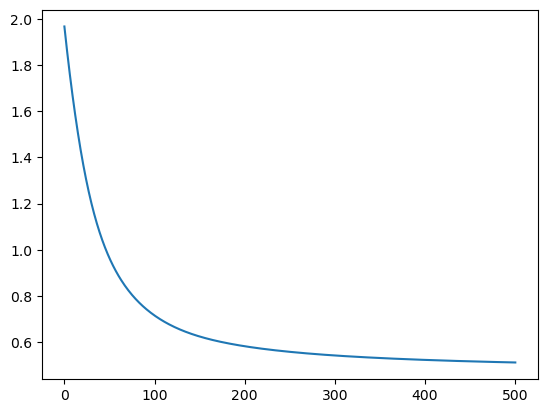

In [241]:
import matplotlib.pyplot as plt
x = np.arange(0,501)
plot = plt.plot (x, np.array(losses))


In [ ]:
import seaborn as sns
import numpy as np
sample = 9
sns.set_theme(style="whitegrid")
print(model(data.x, adj_sparse).shape)
pred = model(data.x, adj_sparse)
probs = torch.exp(pred)
sns.barplot(x=np.array(range(7)), y=probs[sample].detach().cpu().numpy())

In [243]:
accuracy, pred = test3()
accuracy

0.689

## Apply an Attention Parameter?

myGANmodel(
  (layer1): claude_GAN_layer (1433 -> 16)
  (layer2): myGCNLayer (16 -> 7)
)


Epoch: 000, Loss: 1.9122
Epoch: 100, Loss: 1.9122
Epoch: 200, Loss: 1.9122
Epoch: 300, Loss: 1.9122
Epoch: 400, Loss: 1.9122
Epoch: 500, Loss: 1.9122


0.14